# Importing Libraries

In [1]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

2026-04-12 11:58:14.192131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775995094.413009      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775995094.477907      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775995094.964228      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775995094.964270      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775995094.964273      23 computation_placer.cc:177] computation placer alr

# Defining Functions

In [2]:
def data_generator(X, y, batch_size=32):
    """
    Yields dense batches of data from a sparse matrix to save memory.
    """
    num_samples = X.shape[0]
    
    # Convert pandas Series to numpy arrays for easier slicing
    if isinstance(y, pd.Series):
        y = y.values
        
    while True:
        # Shuffle indices at the start of each epoch for better training
        indices = np.random.permutation(num_samples)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_idx = indices[start:end]
            
            # Slice the sparse matrix, then convert ONLY this tiny batch to dense
            X_batch = X[batch_idx].toarray()
            y_batch = y[batch_idx]
            
            yield X_batch, y_batch

class CustomMetricsPrinter(tf.keras.callbacks.Callback):
    def __init__(self, config):
        super().__init__()
        self.config = config

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss', 0.0)
        acc = logs.get('accuracy', 0.0)
        val_loss = logs.get('val_loss', 0.0)
        val_acc = logs.get('val_accuracy', 0.0)
        epochs = self.params['epochs']
        
        print(f"Config: {self.config}, Epoch {epoch + 1}/{epochs}")
        print(f"train_accuracy: {acc:.4f} - train_loss: {loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

# Readind data

In [3]:
print("Loading data...")
# Replace these filenames with your actual file paths

account = 'ayusheinsteinyadav'
dataset = 'original'
# dataset = 'one-percent'
train_df  = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/train.parquet')
val_df    = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/val.parquet')
test_df   = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/test.parquet')


print(f"{dataset} Data Loaded")

num_classes = train_df['generated_by'].unique().tolist().__len__()
print(num_classes, "Classes")

text_col = 'text'
label_col = 'generated_by'

Loading data...
original Data Loaded
12 Classes


# Splitting Data

In [4]:
X_train_raw,  y_train  = train_df[text_col],  train_df[label_col]
X_val_raw,    y_val    = val_df[text_col],    val_df[label_col]
X_test_raw,   y_test   = test_df[text_col],   test_df[label_col]

# Encoding Labels

In [5]:
print("Encoding labels to integers...")
# Initialize the encoder
label_encoder = LabelEncoder()

# Fit on the training labels and transform them to integers
y_train = label_encoder.fit_transform(y_train)

# Transform validation and test labels based on what it learned from training
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

# We can also dynamically figure out how many classes you have!
classes = label_encoder.classes_
num_classes = len(classes)
print(f"Detected {num_classes} unique classes:", *classes, sep = "\n")
print('Labels Encoded Successfully')

Encoding labels to integers...
Detected 12 unique classes:
chatgpt
cohere
cohere-chat
gpt2
gpt3
gpt4
human
llama-chat
mistral
mistral-chat
mpt
mpt-chat
Labels Encoded Successfully


# TF-IDF Tokenization

In [6]:
print("Applying TF-IDF...")

# Limiting max_features to save memory when converting to dense arrays later
# Added ngram_range=(1, 2) to include both single words and 2-word phrases
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 3))

# Fit ONLY on training data to avoid data leakage, then transform all
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf   = tfidf.transform(X_val_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print("TF-IDF Applied")

Applying TF-IDF...
TF-IDF Applied


# Embeding Model Placeholder

In [7]:
X_train_final  = X_train_tfidf
X_val_final    = X_val_tfidf
X_test_final   = X_test_tfidf

del X_train_tfidf, X_val_tfidf, X_test_tfidf
del X_train_raw, X_val_raw, X_test_raw
del train_df, val_df, test_df
gc.collect()
print("Memory Cleared")

Memory Cleared


# Neural Network Hyperparameter Tuning

In [8]:
print("Training and tuning Neural Networks...")
    
# List of tuples defining the sizes of (Hidden Layer 1, Hidden Layer 2)
layer_configs = [(512, 256), (1024, 512)]
# layer_configs = [(2048, 1024), (4096, 2048)]
# layer_configs = [(8192, 16384)]

# CHANGE 1: We now want the LOWEST loss, so we initialize with infinity
best_val_loss = float('inf') 
best_val_acc = 0.0 # We keep this just so we can report the accuracy of the best model
best_config = None
best_model = None

# Determine input shape dynamically based on your final features
input_dim = X_train_final.shape[1]

for config in layer_configs:
    neurons_l1, neurons_l2 = config
    print(f"\nTraining config: Layer 1 = {neurons_l1} neurons, Layer 2 = {neurons_l2} neurons")
        
    # Build the 2-hidden-layer model
    model = Sequential([
        Input(shape=(input_dim,)), 
        
        Dense(neurons_l1, activation='relu'),
        BatchNormalization(), # <-- Helps the model train faster and more stably
        Dropout(0.5),         # <-- Slightly higher dropout to prevent overfitting
        
        Dense(neurons_l2, activation='relu'),
        BatchNormalization(), 
        Dropout(0.3),
        
        Dense(num_classes, activation='softmax') 
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
    batch_size = 32
        
    # We have to tell Keras how many batches make up one full epoch
    steps_per_epoch = int(np.ceil(X_train_final.shape[0] / batch_size))
    val_steps = int(np.ceil(X_val_final.shape[0] / batch_size))

    # Train the model using the generator AND the callback
    # Train the model using the generator AND the callback
    model.fit(
        data_generator(X_train_final, y_train, batch_size),
        validation_data=data_generator(X_val_final, y_val, batch_size),
        steps_per_epoch=steps_per_epoch,
        validation_steps=val_steps,
        epochs=50, # <-- INCREASE THIS!
        verbose=0, 
        callbacks=[CustomMetricsPrinter(config)]
    )
        
    # Evaluate on validation set using the generator
    # Because of restore_best_weights, this evaluates the BEST version of this model, not just the last epoch
    val_loss, val_acc = model.evaluate(
        data_generator(X_val_final, y_val, batch_size), 
        steps=val_steps, 
        verbose=0 # Set to 0 to keep the console slightly cleaner
    )
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")

    # CHANGE 4: Keep track of the best model based on MINIMUM loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc # Saving this to print it at the end
        best_config = config
        best_model = model

print(f"\n==========================================")
print(f"BEST CONFIGURATION FOUND (Based on Lowest Val Loss):")
print(f"Layer 1: {best_config[0]} neurons | Layer 2: {best_config[1]} neurons")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Associated Validation Accuracy: {best_val_acc:.4f}")
print(f"==========================================\n")

Training and tuning Neural Networks...

Training config: Layer 1 = 512 neurons, Layer 2 = 256 neurons


I0000 00:00:1775996001.382254      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775996001.389002      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775996004.652165      75 service.cc:152] XLA service 0x7e38d40086f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775996004.652222      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775996004.652228      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775996005.052485      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775996007.289240      75 device_compiler.h:188] Compiled clust

Config: (512, 256), Epoch 1/50
train_accuracy: 0.6014 - train_loss: 1.1432 - val_accuracy: 0.7191 - val_loss: 0.7944
Config: (512, 256), Epoch 2/50
train_accuracy: 0.7312 - train_loss: 0.7730 - val_accuracy: 0.7605 - val_loss: 0.6824
Config: (512, 256), Epoch 3/50
train_accuracy: 0.7841 - train_loss: 0.6227 - val_accuracy: 0.7750 - val_loss: 0.6478
Config: (512, 256), Epoch 4/50
train_accuracy: 0.8135 - train_loss: 0.5370 - val_accuracy: 0.7843 - val_loss: 0.6409
Config: (512, 256), Epoch 5/50
train_accuracy: 0.8325 - train_loss: 0.4824 - val_accuracy: 0.7873 - val_loss: 0.6425
Config: (512, 256), Epoch 6/50
train_accuracy: 0.8455 - train_loss: 0.4453 - val_accuracy: 0.7891 - val_loss: 0.6555
Config: (512, 256), Epoch 7/50
train_accuracy: 0.8537 - train_loss: 0.4212 - val_accuracy: 0.7908 - val_loss: 0.6568
Config: (512, 256), Epoch 8/50
train_accuracy: 0.8604 - train_loss: 0.4017 - val_accuracy: 0.7917 - val_loss: 0.6696
Config: (512, 256), Epoch 9/50
train_accuracy: 0.8655 - train_lo

# Evaluate on Test Data

Evaluating the best model on unseen Test Data...
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 380s 122ms/step
Final Test Accuracy: 0.7908

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      8256
           1       0.86      0.76      0.81      8425
           2       0.84      0.77      0.80      8339
           3       0.82      0.75      0.79      8294
           4       0.86      0.82      0.84      8185
           5       0.92      0.86      0.89      8273
           6       0.85      0.84      0.85      8242
           7       0.90      0.83      0.86      8430
           8       0.77      0.70      0.73      8212
           9       0.44      0.83      0.57      8319
          10       0.83      0.74      0.78      8290
          11       0.85      0.75      0.80      8335

    accuracy                           0.79     99600
   macro avg       0.82      0.79      0.80     99600
weighted avg       0.82      0.79      0

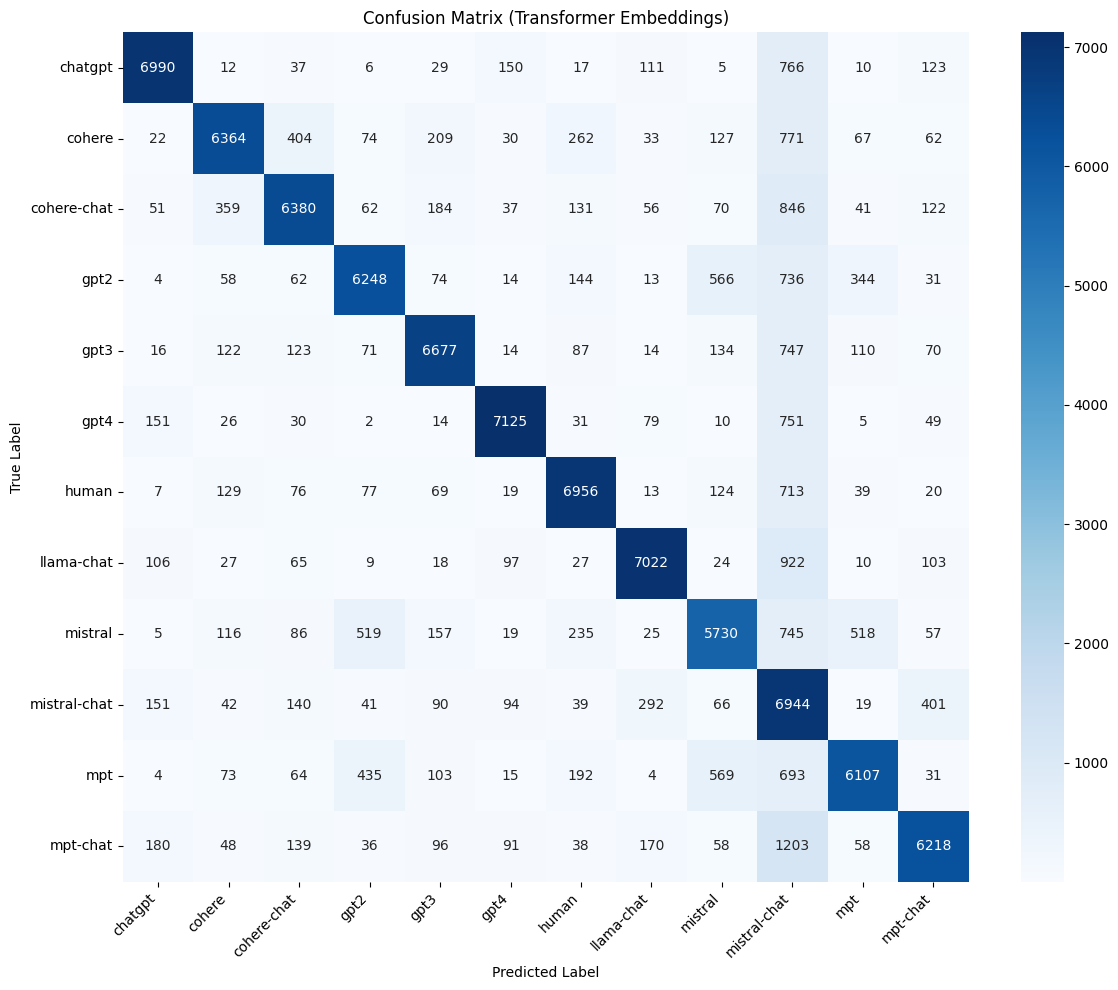

In [9]:
print("Evaluating the best model on unseen Test Data...")
    
# Get probability predictions
y_pred_probs = best_model.predict(X_test_final)
    
# Convert probabilities to 0 or 1 (threshold at 0.5)
# (Note: For multi-class, use y_pred = np.argmax(y_pred_probs, axis=1))
y_pred = np.argmax(y_pred_probs, axis=1)

# Print final metrics
test_acc = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix (Transformer Embeddings)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Testing a custom text

In [10]:
print("Testing Custom String...")

# 1. Define your custom text here
custom_text = "You are correct. But I am a human. The model me will definitely missclassify me as a LLM. Execute the given codes to see for yourself." 

# 2. Transform the text
# We wrap custom_text in a list because tfidf expects an iterable of documents
custom_tfidf = tfidf.transform([custom_text])

# We must convert the sparse matrix to a dense array, just like your data_generator does
custom_dense = custom_tfidf.toarray()

# 3. Get probability predictions
# .predict() returns a 2D array (batch_size, num_classes). 
# We use [0] to grab the predictions for our single string.
probabilities = best_model.predict(custom_dense)[0] 

# 4. Map probabilities to class names
class_names = label_encoder.classes_

# Create a list of tuples: (class_name, probability)
class_probs = list(zip(class_names, probabilities))

# Sort the list by probability in descending order (highest confidence first)
class_probs.sort(key=lambda x: x[1], reverse=True)

# 5. Print the results clearly
print(f"\nInput Text: \n'{custom_text}'\n")
print("="*50)
print(f"🏆 PREDICTED CLASS: {class_probs[0][0]} (Confidence: {class_probs[0][1]*100:.2f}%)")
print("="*50)
print("Confidence distribution across all classes:\n")

# Print formatted list
for class_name, prob in class_probs:
    # .ljust(15) keeps the formatting aligned nicely in the terminal
    print(f"{class_name.ljust(15)} : {prob*100:>7.4f}%")

Testing Custom String...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step

Input Text: 
'You are correct. But I am a human. The model me will definitely missclassify me as a LLM. Execute the given codes to see for yourself.'

🏆 PREDICTED CLASS: mpt-chat (Confidence: 64.19%)
Confidence distribution across all classes:

mpt-chat        : 64.1889%
mistral         : 16.7870%
gpt3            :  5.0975%
cohere-chat     :  3.8776%
mpt             :  3.2747%
cohere          :  2.4910%
human           :  2.3391%
gpt2            :  1.3199%
mistral-chat    :  0.3469%
chatgpt         :  0.1488%
gpt4            :  0.1216%
llama-chat      :  0.0071%
